# CineGraph-AI: Exploratory Data Analysis (EDA)
This notebook analyzes the personal movie archive, focusing on semantic clusters and consumption patterns.

In [3]:
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

# Add src to path
sys.path.insert(0, os.path.abspath('../'))
from src.visualization.visualize import _fetch_data

df = _fetch_data()
X = np.stack(df['embedding'].values)
print(f"Loaded {len(df)} movies with {X.shape[1]} dimensional embeddings.")

Loaded 673 movies with 1536 dimensional embeddings.


## 1. Finding the Optimal Number of Clusters (Elbow Method)
We calculate the inertia (sum of squared distances to the nearest cluster center) for different values of k.

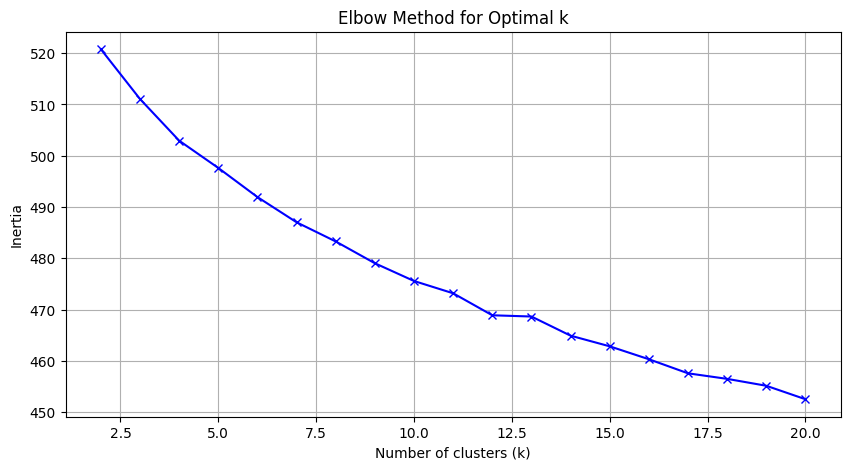

In [4]:
inertias = []
ks = range(2, 21)
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(ks, inertias, 'bx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

## 2. Cluster Profiling
Let's see the distribution of ratings and years across clusters.

15:39:19 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
15:39:19 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


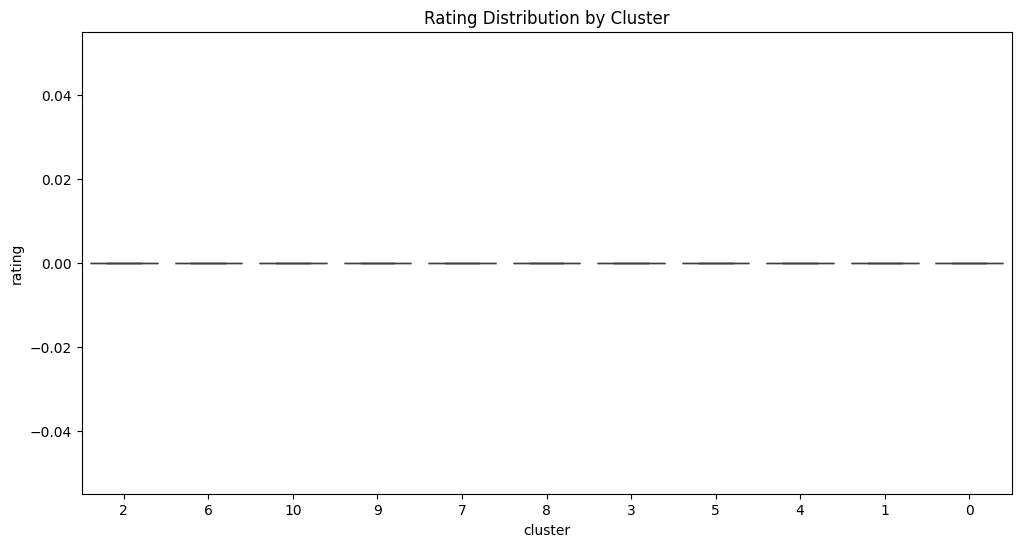

In [6]:
k_optimal = 11
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X).astype(str)

plt.figure(figsize=(12, 6))
sns.boxplot(x='cluster', y='rating', data=df)
plt.title('Rating Distribution by Cluster')
plt.show()

## 3. Genre vs Semantic Map
How genres are distributed in the 2D space.

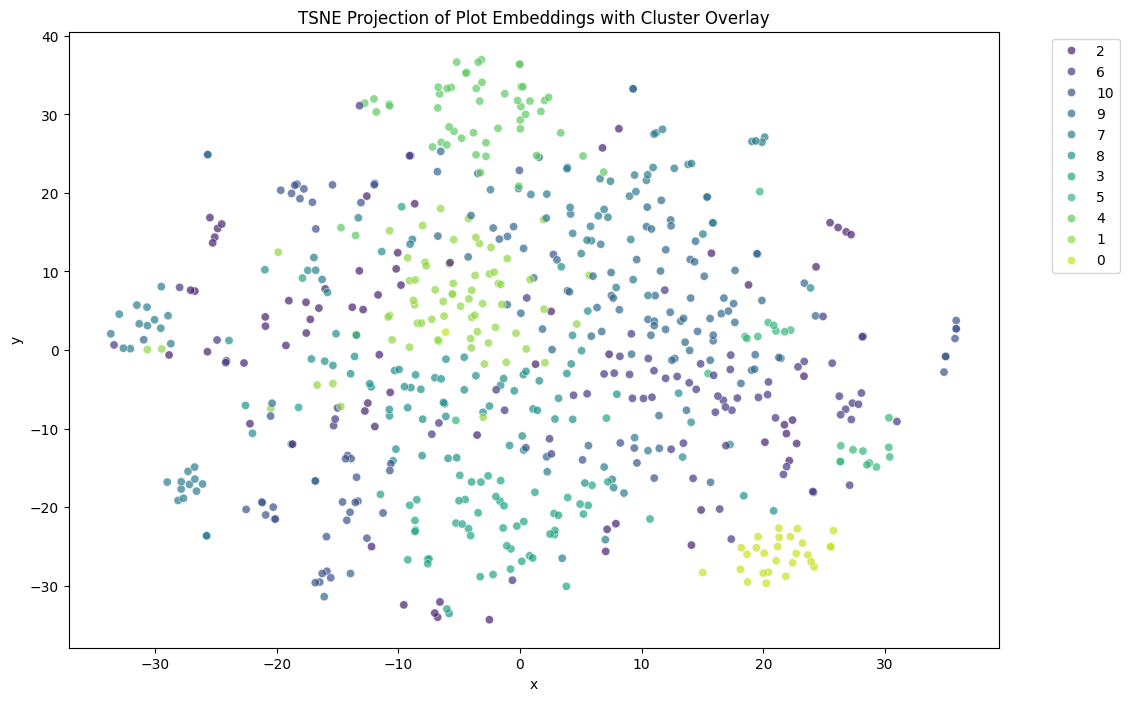

In [7]:
tsne = TSNE(n_components=2, random_state=42)
X_2d = tsne.fit_transform(X)
df['x'], df['y'] = X_2d[:, 0], X_2d[:, 1]

plt.figure(figsize=(12, 8))
sns.scatterplot(x='x', y='y', hue='cluster', data=df, palette='viridis', alpha=0.7)
plt.title('TSNE Projection of Plot Embeddings with Cluster Overlay')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()